# SIT307 11.1HD — Part 2: A leakage-free, nested cross-validated stacking protocol

**Limitation addressed.** Part 1 showed that the Kaggle file contains only 302 unique records among 1025 rows, and that with the paper's random 80/20 row split about 97% of test rows have an identical copy in the training set. Models that can memorise (DT, RF, XGB, stacking) reach ~99–100% on those seen rows. The paper's evaluation therefore does not measure performance on *new* patients. In addition the paper uses one split without a seed, and reports no hyperparameter tuning, so its claim that stacking "considerably enhances" the base classifiers is not supported by a valid comparison.

**Proposed solution.** A redesigned experimental protocol and learning pipeline:
1. **Record-level deduplication before any split**, so that no record can appear on both sides of a split.
2. **Repeated stratified k-fold outer CV** (5 folds × 10 repeats = 50 test folds) instead of a single split, reporting mean and a corrected 95% confidence interval.
3. **Nested hyperparameter optimisation**: each base classifier is grid-searched with an inner 5-fold CV on the outer training fold only (complexity controls such as tree depth, leaf size, K, regularisation).
4. **Stacking of the tuned base classifiers** (out-of-fold probabilities, Logistic Regression meta-learner), compared against the paper's default configuration.
5. **Statistical comparison** with the Nadeau–Bengio corrected resampled t-test, instead of declaring a winner from single numbers.

**How effectiveness is demonstrated.**
- *Experiment 1 (validity of the estimate):* a set of unique records is held out as never-seen patients. Each protocol produces an internal performance estimate on the remaining development data; the protocol whose estimate is closer to the true held-out performance is the more valid one.
- *Experiment 2 (performance of the proposed pipeline):* nested repeated CV on the 302 unique records, comparing default vs tuned models and stacking vs the best single model.

Preprocessing (regression imputation of invalid codes, one-hot encoding, min–max scaling) is identical to Part 1 and is fitted inside every training fold.

In [1]:
import sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RepeatedStratifiedKFold, StratifiedShuffleSplit)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.base import clone

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from heart_utils import load_data, FEATURES, TARGET, MODEL_ORDER, overlap_rate, evaluate
from sklearn.metrics import brier_score_loss
from proposed import (add_record_id, tune_base_models, make_tuned_pipelines,
                      make_default_pipelines, score_model, corrected_resampled_ttest, mean_ci,
                      BASE_ORDER, PARAM_GRIDS, holm_adjust)
from scipy import stats

DATA_PATH = ROOT / "data" / "heart.csv"
FIG_DIR = ROOT / "figures"; FIG_DIR.mkdir(exist_ok=True)
RES_DIR = ROOT / "results"; RES_DIR.mkdir(exist_ok=True)

N_REP_EXP1 = 20      # repetitions of the held-out-patients experiment
OUTER_SPLITS, OUTER_REPEATS = 5, 10   # nested CV: 5 folds x 10 repeats = 50 outer folds
METRICS = ["Accuracy", "Precision", "Recall", "F1", "AUC", "Specificity", "MCC", "Brier"]
pd.set_option("display.precision", 4)

raw = add_record_id(load_data(DATA_PATH))
uniq = raw.drop_duplicates("record_id").reset_index(drop=True)   # one copy per record
print(f"Raw rows: {len(raw)} | unique records: {uniq.record_id.nunique()} | "
      f"class counts (unique): {uniq[TARGET].value_counts().sort_index().to_dict()}")

Raw rows: 1025 | unique records: 302 | class counts (unique): {0: 138, 1: 164}


## Experiment 1 — Which protocol gives a valid estimate for unseen patients?

Repeated `N_REP_EXP1` times with different seeds:
1. The 302 unique records are split (stratified) into **development (80%)** and **held-out patients (20%)**. Held-out records, and all their copies, never touch any training or tuning step.
2. **Paper protocol:** all rows of the development records (duplicates included, as in the paper) are split randomly 80/20 by row; the model is trained on 80% and scored on 20%. This is the *internal estimate* the paper would report.
3. **Proposed protocol:** development records are deduplicated and scored with stratified 5-fold CV. This is the *internal estimate* of the proposed protocol.
4. **Ground truth:** each protocol's final model is trained on its full development data and scored on the held-out patients.

The same model (the paper's default stacking) is used in both protocols, so any difference is caused by the evaluation protocol alone. **Optimism = internal estimate − held-out performance**; a valid protocol has optimism close to 0.

In [2]:
def fit_truth(stack, train_rows, hold):
    # Train on the development data, score on held-out patients, return metrics and meta-learner weights
    model = clone(stack).fit(train_rows[FEATURES], train_rows[TARGET])
    y_pred = model.predict(hold[FEATURES]); y_score = model.predict_proba(hold[FEATURES])[:, 1]
    res = evaluate(hold[TARGET], y_pred, y_score)
    coef = model.named_steps["clf"].final_estimator_.coef_[0]   # one weight per base model (binary task)
    return res, coef

def exp1_once(seed):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    dev_idx, hold_idx = next(sss.split(uniq[FEATURES], uniq[TARGET]))
    dev_ids = set(uniq.record_id.iloc[dev_idx]); hold = uniq.iloc[hold_idx]
    dev_rows = raw[raw.record_id.isin(dev_ids)]            # with duplicates (paper style)
    dev_uniq = uniq[uniq.record_id.isin(dev_ids)]           # deduplicated (proposed)
    assert not set(hold.record_id) & dev_ids                # no held-out record in development data
    stack = make_default_pipelines(seed)["Stacking"]
    out = []

    # Paper protocol: internal random 80/20 row split
    tr, te = train_test_split(dev_rows.index, test_size=0.2, random_state=seed)
    est = score_model(stack, dev_rows.loc[tr, FEATURES], dev_rows.loc[tr, TARGET],
                      dev_rows.loc[te, FEATURES], dev_rows.loc[te, TARGET])
    true, coef = fit_truth(stack, dev_rows, hold)
    ov = overlap_rate(dev_rows.loc[tr, FEATURES + [TARGET]], dev_rows.loc[te, FEATURES + [TARGET]])
    out.append({"seed": seed, "protocol": "Paper (row split, duplicates)", "overlap": ov,
                **{f"est_{m}": est[m] for m in ["Accuracy", "F1", "AUC"]},
                **{f"true_{m}": true[m] for m in ["Accuracy", "F1", "AUC"]},
                **{f"coef_{n}": c for n, c in zip(BASE_ORDER, coef)}})

    # Proposed protocol: deduplicated, stratified 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold = [score_model(stack, dev_uniq[FEATURES].iloc[a], dev_uniq[TARGET].iloc[a],
                        dev_uniq[FEATURES].iloc[b], dev_uniq[TARGET].iloc[b])
            for a, b in cv.split(dev_uniq[FEATURES], dev_uniq[TARGET])]
    est = {m: np.mean([f[m] for f in fold]) for m in ["Accuracy", "F1", "AUC"]}
    true, coef = fit_truth(stack, dev_uniq, hold)
    out.append({"seed": seed, "protocol": "Proposed (dedup + CV)", "overlap": 0.0,
                **{f"est_{m}": est[m] for m in ["Accuracy", "F1", "AUC"]},
                **{f"true_{m}": true[m] for m in ["Accuracy", "F1", "AUC"]},
                **{f"coef_{n}": c for n, c in zip(BASE_ORDER, coef)}})
    return out

t0 = time.time()
exp1 = pd.DataFrame([r for s in range(N_REP_EXP1) for r in exp1_once(s)])
for m in ["Accuracy", "F1", "AUC"]:
    exp1[f"optimism_{m}"] = exp1[f"est_{m}"] - exp1[f"true_{m}"]
exp1.to_csv(RES_DIR / "part2_exp1_raw.csv", index=False)
print(f"Experiment 1 finished in {time.time() - t0:.0f} s")

exp1_summary = exp1.groupby("protocol").agg(
    overlap=("overlap", "mean"),
    internal_acc=("est_Accuracy", "mean"), heldout_acc=("true_Accuracy", "mean"),
    optimism_acc_mean=("optimism_Accuracy", "mean"), optimism_acc_std=("optimism_Accuracy", "std"),
    abs_error_acc=("optimism_Accuracy", lambda x: np.abs(x).mean()),
    internal_auc=("est_AUC", "mean"), heldout_auc=("true_AUC", "mean"),
    optimism_auc_mean=("optimism_AUC", "mean"))
exp1_summary.to_csv(RES_DIR / "part2_exp1_summary.csv")
display(exp1_summary)

Experiment 1 finished in 146 s


,overlap,internal_acc,heldout_acc,optimism_acc_mean,optimism_acc_std,abs_error_acc,internal_auc,heldout_auc,optimism_auc_mean
protocol,,,,,,,,,
"Paper (row split, duplicates)",0.9713,0.9963,0.7893,0.2070,0.0442,0.207,0.9998,0.8788,0.1209
Proposed (dedup + CV),0.0000,0.8328,0.8287,0.0041,0.0647,0.051,0.9070,0.9067,0.0003


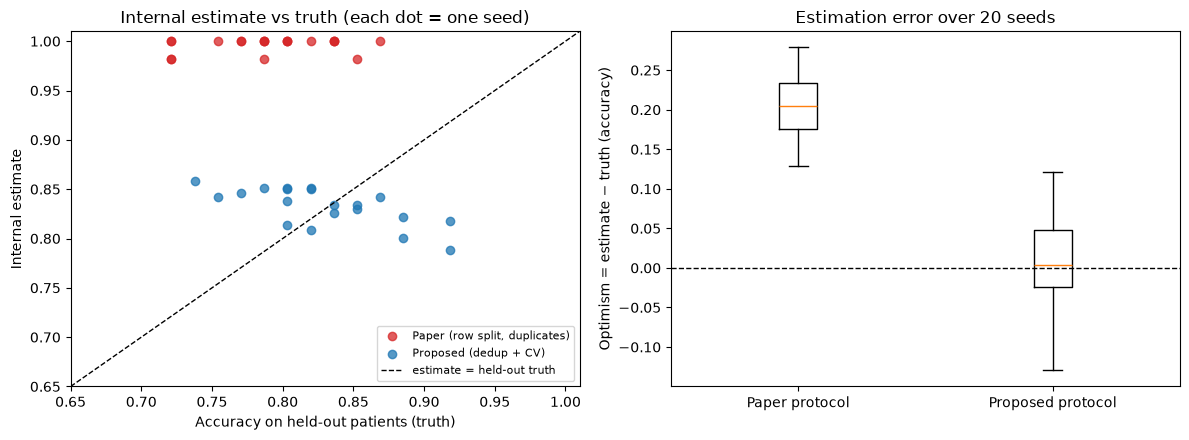

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"Paper (row split, duplicates)": "tab:red", "Proposed (dedup + CV)": "tab:blue"}
for p, g in exp1.groupby("protocol"):
    axes[0].scatter(g["true_Accuracy"], g["est_Accuracy"], label=p, color=colors[p], alpha=0.75)
lo, hi = 0.65, 1.01
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="estimate = held-out truth")
axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
axes[0].set_xlabel("Accuracy on held-out patients (truth)"); axes[0].set_ylabel("Internal estimate")
axes[0].set_title("Internal estimate vs truth (each dot = one seed)"); axes[0].legend(fontsize=8)

order = list(colors)
axes[1].boxplot([exp1.loc[exp1.protocol == p, "optimism_Accuracy"] for p in order],
                tick_labels=["Paper protocol", "Proposed protocol"])
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set_ylabel("Optimism = estimate − truth (accuracy)")
axes[1].set_title(f"Estimation error over {N_REP_EXP1} seeds")
fig.tight_layout(); fig.savefig(FIG_DIR / "p2_exp1_estimate_validity.png", dpi=200); plt.show()

**Caveat.** Each held-out set contains only about 60 patients, so the held-out "truth" of a single seed is itself noisy; this is why the blue points do not lie exactly on the diagonal. The relevant property is **bias**: averaged over seeds, the proposed protocol's estimate is centred on the truth, whereas the paper's protocol is shifted upward in every seed.

### Experiment 1b — Do duplicates also harm the *trained model*?

The two protocols also produce different final models: the paper's is trained on the development rows with duplicates, the proposed one on the deduplicated records. Both are scored on the **same held-out patients** in each seed, so they can be compared with a paired test.

Hypothesised mechanism: stacking builds its meta-features with an internal 5-fold CV. With duplicates, copies of a record fall into both the internal training and validation folds, so the memorising base models (DT, RF, XGB) look almost perfect in the out-of-fold predictions, and the meta-learner may give them too much weight. This is checked by comparing the meta-learner (Logistic Regression) coefficients learned in the two settings.

,trained with duplicates,trained deduplicated,mean diff (dedup - dup),seeds where dedup better,paired t-test p
metric (held-out),,,,,
Accuracy,0.7893,0.8287,0.0393,16/20,0.0058
AUC,0.8788,0.9067,0.0279,20/20,0.0000
F1,0.8054,0.8451,0.0398,16/20,0.0031


Mean meta-learner (LR) coefficient per base model over seeds:


,trained with duplicates,trained deduplicated
LR,0.525,1.868
DT,2.828,0.133
RF,2.830,1.386
XGB,3.212,0.712
NB,0.534,0.459
KNN,0.725,0.870


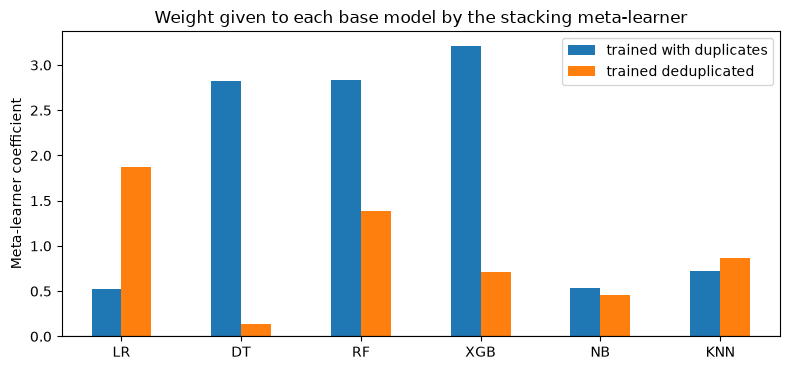

In [4]:
paper_p = exp1[exp1.protocol.str.startswith("Paper")].set_index("seed")
prop_p = exp1[exp1.protocol.str.startswith("Proposed")].set_index("seed")
rows = []
for m in ["Accuracy", "AUC", "F1"]:
    d = prop_p[f"true_{m}"] - paper_p[f"true_{m}"]
    rows.append({"metric (held-out)": m,
                 "trained with duplicates": paper_p[f"true_{m}"].mean(),
                 "trained deduplicated": prop_p[f"true_{m}"].mean(),
                 "mean diff (dedup - dup)": d.mean(),
                 "seeds where dedup better": f"{int((d > 0).sum())}/{len(d)}",
                 "paired t-test p": stats.ttest_rel(prop_p[f"true_{m}"], paper_p[f"true_{m}"]).pvalue})
dup_effect = pd.DataFrame(rows).set_index("metric (held-out)")
dup_effect.to_csv(RES_DIR / "part2_exp1b_duplicate_training_effect.csv")
display(dup_effect.round(4))

coef_cols = [f"coef_{n}" for n in BASE_ORDER]
coefs = pd.DataFrame({"trained with duplicates": paper_p[coef_cols].mean(),
                      "trained deduplicated": prop_p[coef_cols].mean()})
coefs.index = BASE_ORDER
coefs.to_csv(RES_DIR / "part2_exp1b_meta_coefficients.csv")
print("Mean meta-learner (LR) coefficient per base model over seeds:")
display(coefs.round(3))

fig, ax = plt.subplots(figsize=(8, 3.8))
coefs.plot.bar(ax=ax, rot=0)
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("Meta-learner coefficient")
ax.set_title("Weight given to each base model by the stacking meta-learner")
fig.tight_layout(); fig.savefig(FIG_DIR / "p2_exp1b_meta_coefficients.png", dpi=200); plt.show()

## Experiment 2 — Nested repeated CV on the 302 unique records

For each of the 50 outer folds:
- **Default** configuration (paper settings, library defaults) for the six classifiers and stacking is trained on the outer training fold and scored on the outer test fold.
- **Tuned** configuration (proposed): every base classifier is grid-searched (`PARAM_GRIDS`, ROC-AUC, inner stratified 5-fold CV) on the outer training fold only; the tuned classifiers and the stacking of the tuned classifiers are then trained on the full outer training fold and scored on the outer test fold.

The outer test fold is never used for tuning or model selection. Inside the stacking model, the unsupervised preprocessing (imputer, encoder, scaler) is fitted on the whole outer training fold before stacking creates its internal folds. It uses no labels and never sees the outer test fold, so its effect on the reported estimates is negligible. Out-of-fold predictions of the first repeat (every record predicted exactly once) are stored for the confusion matrix and ROC curves.

Finished folds are cached in `results/cache/`, so an interrupted run resumes where it stopped. Grid search uses all available cores (`n_jobs=-1`).

In [5]:
import pickle
from proposed import run_outer_fold, OOF_KEYS
X, y = uniq[FEATURES].reset_index(drop=True), uniq[TARGET].reset_index(drop=True)
outer = RepeatedStratifiedKFold(n_splits=OUTER_SPLITS, n_repeats=OUTER_REPEATS, random_state=2024)

# Each outer fold is saved to results/cache/ so that an interrupted run can resume.
# Delete results/cache/ to recompute everything from scratch.
CACHE_DIR = RES_DIR / "cache"; CACHE_DIR.mkdir(exist_ok=True)
records, params_log = [], []
oof = {k: np.full(len(y), np.nan) for k in OOF_KEYS}
oof_pred = {k: np.full(len(y), -1) for k in OOF_KEYS}

t0 = time.time()
for fold_id, (tr, te) in enumerate(outer.split(X, y)):
    f = CACHE_DIR / f"exp2_fold{fold_id:02d}_of{OUTER_SPLITS}x{OUTER_REPEATS}.pkl"
    if f.exists():
        rec, par, fold_oof = pickle.loads(f.read_bytes())
    else:
        rec, par, fold_oof = run_outer_fold(fold_id, tr, te, X, y, OUTER_SPLITS)
        f.write_bytes(pickle.dumps((rec, par, fold_oof)))
    records += rec; params_log.append(par)
    if fold_id < OUTER_SPLITS:                     # first repeat: every record predicted once
        for key, (idx, score, pred) in fold_oof.items():
            oof[key][idx] = score; oof_pred[key][idx] = pred
    if (fold_id + 1) % 10 == 0:
        print(f"outer fold {fold_id + 1}/{OUTER_SPLITS * OUTER_REPEATS} done, {time.time() - t0:.0f} s elapsed")

exp2 = pd.DataFrame(records)
exp2.to_csv(RES_DIR / "part2_exp2_raw.csv", index=False)
params_df = pd.DataFrame(params_log); params_df.to_csv(RES_DIR / "part2_exp2_best_params.csv", index=False)
print(f"Experiment 2: {exp2.fold.nunique()} outer folds, {time.time() - t0:.0f} s")

outer fold 10/50 done, 102 s elapsed
outer fold 20/50 done, 193 s elapsed
outer fold 30/50 done, 288 s elapsed
outer fold 40/50 done, 381 s elapsed
outer fold 50/50 done, 474 s elapsed
Experiment 2: 50 outer folds, 474 s


### 2.1 Results: mean and corrected 95% confidence interval over 50 outer folds

The confidence interval uses the Nadeau–Bengio variance correction (outer training sets overlap, so the naive standard error is too small).

In [6]:
n_train, n_test = exp2["n_train"].mean(), exp2["n_test"].mean()
rows = []
for (config, name), g in exp2.groupby(["config", "model"]):
    r = {"config": config, "model": name}
    for m in METRICS:
        mu, h = mean_ci(g[m], n_train, n_test); r[m] = mu; r[f"{m} ±CI"] = h
    rows.append(r)
exp2_summary = pd.DataFrame(rows)
exp2_summary["model"] = pd.Categorical(exp2_summary["model"], MODEL_ORDER, ordered=True)
exp2_summary = exp2_summary.sort_values(["config", "model"]).set_index(["config", "model"])
exp2_summary.to_csv(RES_DIR / "part2_exp2_summary.csv")
display(exp2_summary[["Accuracy", "Accuracy ±CI", "Precision", "Recall", "F1", "AUC", "AUC ±CI",
                      "Specificity", "MCC", "Brier"]])

Accuracy  Accuracy ±CI  Precision  Recall      F1     AUC  \
config  model                                                                 
Default LR          0.8470        0.0490     0.8473  0.8799  0.8621  0.9127   
        DT          0.7441        0.0608     0.7721  0.7540  0.7605  0.7428   
        RF          0.8229        0.0516     0.8274  0.8549  0.8395  0.8997   
        XGB         0.8050        0.0445     0.8136  0.8352  0.8224  0.8809   
        NB          0.8048        0.0742     0.8056  0.8600  0.8261  0.8767   
        KNN         0.8205        0.0429     0.8372  0.8334  0.8340  0.8668   
        Stacking    0.8338        0.0452     0.8346  0.8688  0.8501  0.9046   
Tuned   LR          0.8404        0.0473     0.8400  0.8756  0.8562  0.9088   
        DT          0.7719        0.0601     0.7862  0.8005  0.7897  0.8366   
        RF          0.8315        0.0558     0.8280  0.8738  0.8491  0.9072   
        XGB         0.8246        0.0501     0.8244  0.8622  0.8414  0.8968   
        NB          0.8204        0.0592     0.8241  0.8602  0.8389  0.8767   
        KNN         0.8249        0.0472     0.8340  0.8487  0.8398  0.9014   
        Stacking    0.8348        0.0467     0.8343  0.8719  0.8510  0.9106   

                  AUC ±CI  Specificity     MCC   Brier  
config  model                                           
Default LR         0.0318       0.8077  0.6935  0.1168  
        DT         0.0610       0.7317  0.4887  0.2559  
        RF         0.0362       0.7845  0.6450  0.1276  
        XGB        0.0366       0.7687  0.6095  0.1539  
        NB         0.0415       0.7388  0.6153  0.1758  
        KNN        0.0485       0.8048  0.6407  0.1448  
        Stacking   0.0346       0.7917  0.6668  0.1226  
Tuned   LR         0.0345       0.7984  0.6801  0.1227  
        DT         0.0401       0.7374  0.5453  0.1685  
        RF         0.0386       0.7809  0.6620  0.1294  
        XGB        0.0363       0.7795  0.6487  0.1304  
        NB         0.0416       0.7728  0.6424  0.1595  
        KNN        0.0376       0.7960  0.6492  0.1271  
        Stacking   0.0325       0.7903  0.6696  0.1208

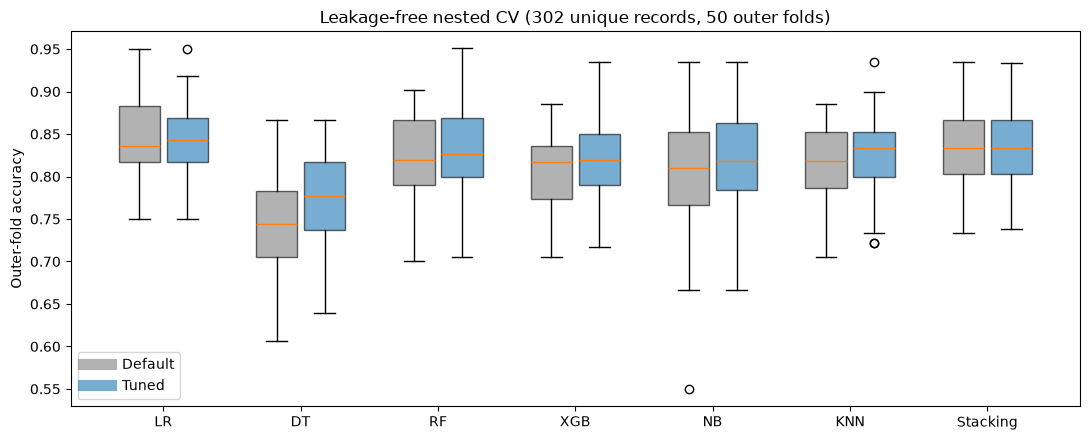

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
pos = np.arange(len(MODEL_ORDER))
for k, (config, col) in enumerate([("Default", "tab:gray"), ("Tuned", "tab:blue")]):
    data = [exp2.loc[(exp2.config == config) & (exp2.model == m), "Accuracy"] for m in MODEL_ORDER]
    bp = ax.boxplot(data, positions=pos + (k - 0.5) * 0.35, widths=0.3, patch_artist=True)
    for b in bp["boxes"]: b.set_facecolor(col); b.set_alpha(0.6)
    ax.plot([], [], color=col, lw=8, alpha=0.6, label=config)
ax.set_xticks(pos); ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel("Outer-fold accuracy"); ax.set_title(f"Leakage-free nested CV ({len(y)} unique records, {exp2.fold.nunique()} outer folds)")
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / "p2_exp2_default_vs_tuned.png", dpi=200); plt.show()

### 2.2 Statistical comparisons (corrected resampled t-test, paired on the same 50 outer folds)

Three questions:
1. Does nested tuning change each model's performance compared with the paper's defaults?
2. Does stacking of tuned models beat each tuned base model?
3. Under leakage-free evaluation, does the paper's own (default) stacking beat its best default single model?

Positive `mean diff` means the first model is better. Because many tests are run (14 per metric), p-values are also adjusted with the **Holm–Bonferroni** method within each metric; conclusions are based on the adjusted value `p_holm`.

In [8]:
def pivot(config, metric):
    return exp2[exp2.config == config].pivot(index="fold", columns="model", values=metric)

tests = []
for metric in ["Accuracy", "AUC", "F1"]:
    D, T = pivot("Default", metric), pivot("Tuned", metric)
    for m in MODEL_ORDER:
        d, t, p = corrected_resampled_ttest(T[m], D[m], n_train, n_test)
        tests.append({"question": "1. Tuned vs Default", "comparison": f"{m} tuned − {m} default",
                      "metric": metric, "mean diff": d, "t": t, "p": p})
    for m in BASE_ORDER:
        d, t, p = corrected_resampled_ttest(T["Stacking"], T[m], n_train, n_test)
        tests.append({"question": "2. Tuned stacking vs tuned base", "comparison": f"Stacking − {m}",
                      "metric": metric, "mean diff": d, "t": t, "p": p})
    best_default = D[BASE_ORDER].mean().idxmax()
    d, t, p = corrected_resampled_ttest(D["Stacking"], D[best_default], n_train, n_test)
    tests.append({"question": "3. Default stacking vs best default base",
                  "comparison": f"Stacking − {best_default}", "metric": metric,
                  "mean diff": d, "t": t, "p": p})
tests = pd.DataFrame(tests)
tests["p_holm"] = tests.groupby("metric")["p"].transform(holm_adjust)
tests["significant (p<0.05)"] = tests["p"] < 0.05
tests["significant after Holm"] = tests["p_holm"] < 0.05
tests.to_csv(RES_DIR / "part2_exp2_tests.csv", index=False)
display(tests[tests.metric == "Accuracy"].round(4))
display(tests[tests.metric == "AUC"].round(4))

,question,comparison,metric,mean diff,t,p,p_holm,significant (p<0.05),significant after Holm
0,1. Tuned vs Default,LR tuned − LR default,Accuracy,-0.0066,-0.6729,0.5042,1.0000,False,False
1,1. Tuned vs Default,DT tuned − DT default,Accuracy,0.0278,0.8589,0.3946,1.0000,False,False
2,1. Tuned vs Default,RF tuned − RF default,Accuracy,0.0086,0.6527,0.5170,1.0000,False,False
3,1. Tuned vs Default,XGB tuned − XGB default,Accuracy,0.0196,1.2952,0.2013,1.0000,False,False
4,1. Tuned vs Default,NB tuned − NB default,Accuracy,0.0156,0.7588,0.4516,1.0000,False,False
5,1. Tuned vs Default,KNN tuned − KNN default,Accuracy,0.0043,0.2446,0.8078,1.0000,False,False
6,1. Tuned vs Default,Stacking tuned − Stacking default,Accuracy,0.0010,0.0811,0.9357,1.0000,False,False
7,2. Tuned stacking vs tuned base,Stacking − LR,Accuracy,-0.0056,-0.4356,0.6650,1.0000,False,False
8,2. Tuned stacking vs tuned base,Stacking − DT,Accuracy,0.0629,2.4208,0.0192,0.2693,True,False
9,2. Tuned stacking vs tuned base,Stacking − RF,Accuracy,0.0033,0.2472,0.8058,1.0000,False,False


,question,comparison,metric,mean diff,t,p,p_holm,significant (p<0.05),significant after Holm
14,1. Tuned vs Default,LR tuned − LR default,AUC,-0.0039,-0.8259,0.4129,1.0000,False,False
15,1. Tuned vs Default,DT tuned − DT default,AUC,0.0937,3.5090,0.0010,0.0127,True,True
16,1. Tuned vs Default,RF tuned − RF default,AUC,0.0076,1.1449,0.2578,1.0000,False,False
17,1. Tuned vs Default,XGB tuned − XGB default,AUC,0.0159,1.3344,0.1882,1.0000,False,False
18,1. Tuned vs Default,NB tuned − NB default,AUC,-0.0000,-0.0024,0.9981,1.0000,False,False
19,1. Tuned vs Default,KNN tuned − KNN default,AUC,0.0345,2.9975,0.0043,0.0512,True,False
20,1. Tuned vs Default,Stacking tuned − Stacking default,AUC,0.0060,1.3668,0.1779,1.0000,False,False
21,2. Tuned stacking vs tuned base,Stacking − LR,AUC,0.0018,0.3164,0.7530,1.0000,False,False
22,2. Tuned stacking vs tuned base,Stacking − DT,AUC,0.0741,5.3092,0.0000,0.0000,True,True
23,2. Tuned stacking vs tuned base,Stacking − RF,AUC,0.0034,0.5167,0.6077,1.0000,False,False



### 2.2b How much do the conclusions depend on the choice of statistical test?

The corrected resampled t-test (Nadeau and Bengio) was derived for repeated random train/test splits; its use for repeated k-fold CV (Bouckaert and Frank) relies on the same approximation of the correlation between folds, which the original authors themselves describe as rough. The p-values above are therefore approximate: the test can still be somewhat liberal if folds are more correlated than assumed, or conservative if less.

To see how much this matters, the key comparisons are repeated with three tests that make different assumptions:
- **Naive paired t-test (50 folds):** treats all folds as independent; known to be too liberal, so it gives a lower bound on the p-value.
- **Corrected resampled t-test (50 folds):** the test used in this study.
- **Paired t-test on repeat means (10 values):** averages the 5 folds of each repeat first, so each value uses every record once; the repeats still share data, so this is a different, not an exact, view.

A conclusion is treated as robust only if it is the same under all three tests.


In [9]:

def naive_paired_t(a, b):
    d = np.asarray(a) - np.asarray(b)
    return stats.ttest_1samp(d, 0.0).pvalue

key_comparisons = [
    ("Default", "Stacking", "Default", "LR", "Accuracy"), ("Default", "Stacking", "Default", "LR", "AUC"),
    ("Tuned", "Stacking", "Tuned", "LR", "Accuracy"), ("Tuned", "Stacking", "Tuned", "LR", "AUC"),
    ("Tuned", "Stacking", "Tuned", "DT", "Accuracy"), ("Tuned", "Stacking", "Tuned", "DT", "AUC"),
    ("Tuned", "DT", "Default", "DT", "AUC"), ("Tuned", "KNN", "Default", "KNN", "AUC"),
]
rows = []
for ca_, ma, cb, mb, metric in key_comparisons:
    A = exp2[(exp2.config == ca_) & (exp2.model == ma)].sort_values("fold")
    B = exp2[(exp2.config == cb) & (exp2.model == mb)].sort_values("fold")
    diff, _, p_corr = corrected_resampled_ttest(A[metric].values, B[metric].values, n_train, n_test)
    p_naive = naive_paired_t(A[metric].values, B[metric].values)
    ra, rb = A.groupby("repeat")[metric].mean(), B.groupby("repeat")[metric].mean()
    p_rep = stats.ttest_rel(ra.values, rb.values).pvalue
    rows.append({"comparison": f"{ma} {ca_.lower()} - {mb} {cb.lower()}", "metric": metric, "mean diff": diff,
                 "p naive (50 folds)": p_naive, "p corrected (50 folds)": p_corr, "p repeat means (10)": p_rep})
test_sens = pd.DataFrame(rows)
pcols = ["p naive (50 folds)", "p corrected (50 folds)", "p repeat means (10)"]
test_sens["significant under all three"] = (test_sens[pcols] < 0.05).all(axis=1)
test_sens["significant under none"] = (test_sens[pcols] >= 0.05).all(axis=1)
test_sens["conclusion depends on test"] = ~(test_sens["significant under all three"] | test_sens["significant under none"])
test_sens.to_csv(RES_DIR / "part2_exp2_test_sensitivity.csv", index=False)
display(test_sens.round(4))


,comparison,metric,mean diff,p naive (50 folds),p corrected (50 folds),p repeat means (10),significant under all three,significant under none,conclusion depends on test
0,Stacking default - LR default,Accuracy,-0.0133,0.0001,0.2664,0.0006,False,False,True
1,Stacking default - LR default,AUC,-0.0080,0.0001,0.2578,0.0001,False,False,True
2,Stacking tuned - LR tuned,Accuracy,-0.0056,0.1159,0.6650,0.1254,False,True,False
3,Stacking tuned - LR tuned,AUC,0.0018,0.2506,0.7530,0.3198,False,True,False
4,Stacking tuned - DT tuned,Accuracy,0.0629,0.0000,0.0192,0.0000,True,False,False
5,Stacking tuned - DT tuned,AUC,0.0741,0.0000,0.0000,0.0000,True,False,False
6,DT tuned - DT default,AUC,0.0937,0.0000,0.0010,0.0000,True,False,False
7,KNN tuned - KNN default,AUC,0.0345,0.0000,0.0043,0.0000,True,False,False



**Interpretation.** Comparisons whose conclusion is the same under all three tests are robust to the approximation in the corrected test. Comparisons marked "conclusion depends on test" sit close to the significance threshold and should not be interpreted as firm evidence either way; this is also why the report gives the Holm-adjusted corrected p-values priority and treats borderline results with caution.


### 2.3 Stability of the selected hyperparameters

How often each setting was selected across the 50 outer folds. Consistent choices indicate that the tuning result is not an artefact of one particular fold.

In [10]:
for name in BASE_ORDER:
    vc = params_df[name].value_counts()
    print(f"{name}: " + "; ".join(f"{k} x{v}" for k, v in vc.head(3).items()))

LR: {'C': 1} x27; {'C': 0.1} x12; {'C': 10} x9
DT: {'max_depth': 4, 'min_samples_leaf': 10} x15; {'max_depth': 5, 'min_samples_leaf': 10} x11; {'max_depth': None, 'min_samples_leaf': 10} x8
RF: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200} x17; {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200} x13; {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200} x9
XGB: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100} x30; {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100} x9; {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300} x4
NB: {'var_smoothing': 0.001} x25; {'var_smoothing': 1e-09} x24; {'var_smoothing': 1e-05} x1
KNN: {'n_neighbors': 31, 'weights': 'uniform'} x16; {'n_neighbors': 31, 'weights': 'distance'} x12; {'n_neighbors': 15, 'weights': 'uniform'} x9


### 2.4 Out-of-fold confusion matrices and ROC curves (first repeat, every record predicted once)

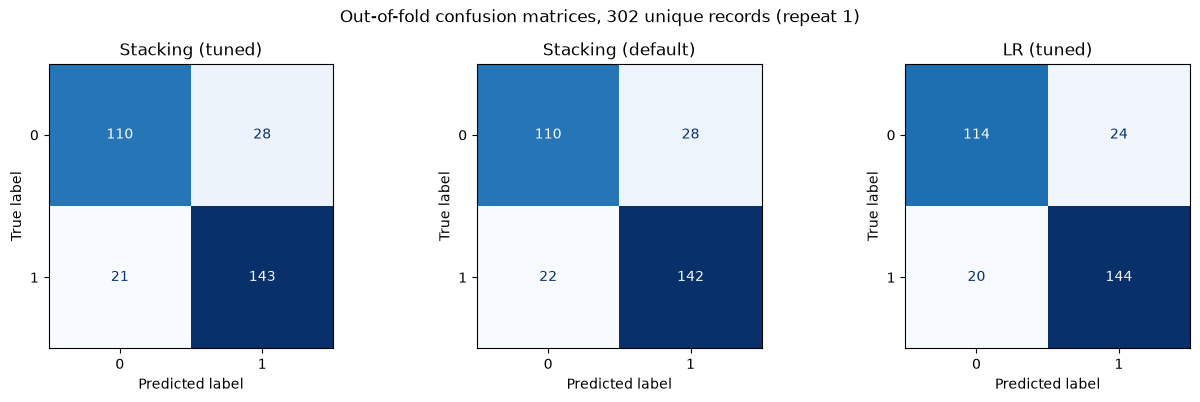

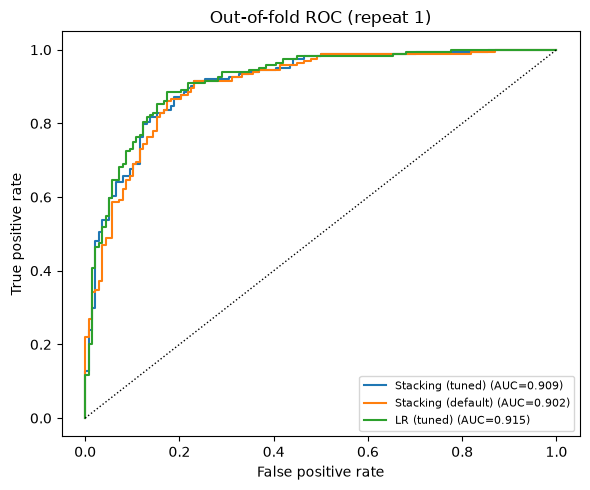

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, key in zip(axes, oof_pred):
    ConfusionMatrixDisplay.from_predictions(y, oof_pred[key], ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(key)
fig.suptitle("Out-of-fold confusion matrices, 302 unique records (repeat 1)"); fig.tight_layout()
fig.savefig(FIG_DIR / "p2_oof_confusion.png", dpi=200); plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for key in oof:
    fpr, tpr, _ = roc_curve(y, oof[key])
    ax.plot(fpr, tpr, label=f"{key} (AUC={roc_auc_score(y, oof[key]):.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Out-of-fold ROC (repeat 1)"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "p2_oof_roc.png", dpi=200); plt.show()

## 3. Comparison: paper vs Part 1 reproduction vs Part 2

- **Paper:** Table 11 (single split, leaky).
- **Part 1 reproduced:** mean over 20 random 80/20 row splits of the 1025-row file (paper protocol).
- **Part 2 default:** paper configuration, leakage-free nested CV (50 outer folds).
- **Part 2 tuned (proposed):** nested tuning + stacking of tuned models, same 50 outer folds.

,Accuracy | Paper,Accuracy | Part 1 (leaky),Accuracy | Part 2 default,Accuracy | Part 2 tuned
LR,0.8439,0.8607,0.8470,0.8404
DT,0.9268,0.9949,0.7441,0.7719
RF,0.9268,0.9971,0.8229,0.8315
XGB,0.9073,0.9954,0.8050,0.8246
NB,0.8439,0.8488,0.8048,0.8204
KNN,0.8585,0.8507,0.8205,0.8249
Stacking,0.9853,0.9978,0.8338,0.8348


,AUC | Paper,AUC | Part 1 (leaky),AUC | Part 2 default,AUC | Part 2 tuned
LR,0.9204,0.9307,0.9127,0.9088
DT,0.9702,0.9951,0.7428,0.8366
RF,0.9734,0.9997,0.8997,0.9072
XGB,0.9830,0.9996,0.8809,0.8968
NB,0.9185,0.9025,0.8767,0.8767
KNN,0.9304,0.9569,0.8668,0.9014
Stacking,0.9880,0.9991,0.9046,0.9106


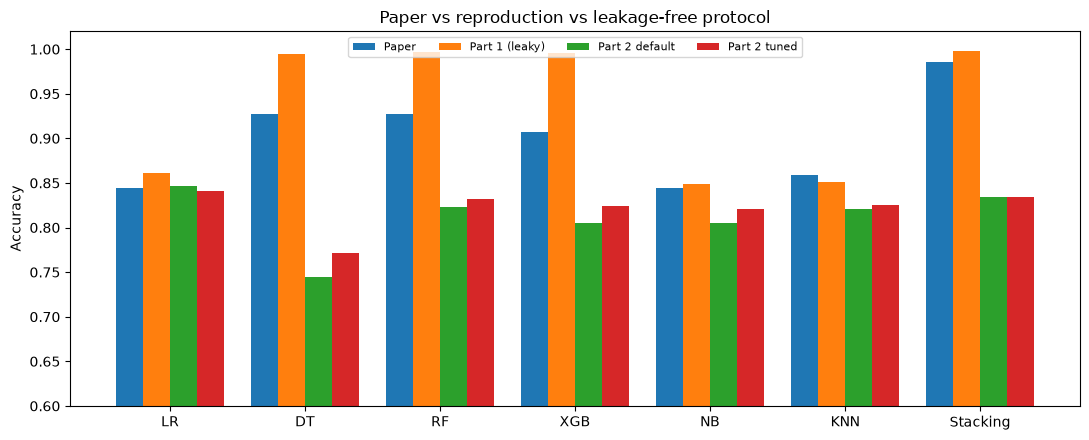

In [12]:
paper = pd.read_csv(RES_DIR / "paper_table11.csv", index_col=0)
p1 = pd.read_csv(RES_DIR / "part1_multiseed_raw.csv").groupby("model")[["Accuracy", "F1", "AUC"]].mean()
final = pd.DataFrame(index=MODEL_ORDER)
for m in ["Accuracy", "F1", "AUC"]:
    final[f"{m} | Paper"] = paper[m]
    final[f"{m} | Part 1 (leaky)"] = p1[m]
    final[f"{m} | Part 2 default"] = exp2_summary.loc["Default", m].reindex(MODEL_ORDER).values
    final[f"{m} | Part 2 tuned"] = exp2_summary.loc["Tuned", m].reindex(MODEL_ORDER).values
final.to_csv(RES_DIR / "final_comparison.csv")
display(final[[c for c in final.columns if c.startswith("Accuracy")]].round(4))
display(final[[c for c in final.columns if c.startswith("AUC")]].round(4))

fig, ax = plt.subplots(figsize=(11, 4.5))
cols = ["Accuracy | Paper", "Accuracy | Part 1 (leaky)", "Accuracy | Part 2 default", "Accuracy | Part 2 tuned"]
w = 0.2; x = np.arange(len(MODEL_ORDER))
for i, c in enumerate(cols):
    ax.bar(x + (i - 1.5) * w, final[c], w, label=c.split(" | ")[1])
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER); ax.set_ylim(0.6, 1.02)
ax.set_ylabel("Accuracy"); ax.set_title("Paper vs reproduction vs leakage-free protocol")
ax.legend(ncol=4, fontsize=8, loc="upper center"); fig.tight_layout()
fig.savefig(FIG_DIR / "p2_final_comparison.png", dpi=200); plt.show()

## 4. Summary

In [13]:
e1 = exp1_summary
print("Experiment 1 - estimate validity (default stacking, accuracy):")
for p in e1.index:
    print(f"  {p:32s} internal {e1.loc[p,'internal_acc']:.3f} | held-out {e1.loc[p,'heldout_acc']:.3f} | "
          f"optimism {e1.loc[p,'optimism_acc_mean']:+.3f} ± {e1.loc[p,'optimism_acc_std']:.3f} | "
          f"mean train/test overlap {e1.loc[p,'overlap']:.1%}")

print(f"\nExperiment 2 - leakage-free accuracy (mean ± corrected 95% CI, {exp2.fold.nunique()} outer folds):")
for config in ["Default", "Tuned"]:
    for m in MODEL_ORDER:
        r = exp2_summary.loc[(config, m)]
        print(f"  {config:7s} {m:9s} {r['Accuracy']:.3f} ± {r['Accuracy ±CI']:.3f} | AUC {r['AUC']:.3f}")

print("\nExperiment 1b - same held-out patients, model trained with vs without duplicates:")
for m in dup_effect.index:
    r = dup_effect.loc[m]
    print(f"  {m:8s} dup {r['trained with duplicates']:.3f} | dedup {r['trained deduplicated']:.3f} | "
          f"diff {r['mean diff (dedup - dup)']:+.3f} | dedup better in {r['seeds where dedup better']} | p={r['paired t-test p']:.4f}")

for metric in ["Accuracy", "AUC"]:
    t = tests[tests.metric == metric]
    print(f"\n{metric}: nominally significant (p < 0.05) | still significant after Holm")
    sig = t[t["significant (p<0.05)"]]
    if len(sig):
        print(sig[["comparison", "mean diff", "p", "p_holm", "significant after Holm"]].round(4).to_string(index=False))
    else:
        print("  none")

Experiment 1 - estimate validity (default stacking, accuracy):
  Paper (row split, duplicates)    internal 0.996 | held-out 0.789 | optimism +0.207 ± 0.044 | mean train/test overlap 97.1%
  Proposed (dedup + CV)            internal 0.833 | held-out 0.829 | optimism +0.004 ± 0.065 | mean train/test overlap 0.0%

Experiment 2 - leakage-free accuracy (mean ± corrected 95% CI, 50 outer folds):
  Default LR        0.847 ± 0.049 | AUC 0.913
  Default DT        0.744 ± 0.061 | AUC 0.743
  Default RF        0.823 ± 0.052 | AUC 0.900
  Default XGB       0.805 ± 0.045 | AUC 0.881
  Default NB        0.805 ± 0.074 | AUC 0.877
  Default KNN       0.821 ± 0.043 | AUC 0.867
  Default Stacking  0.834 ± 0.045 | AUC 0.905
  Tuned   LR        0.840 ± 0.047 | AUC 0.909
  Tuned   DT        0.772 ± 0.060 | AUC 0.837
  Tuned   RF        0.831 ± 0.056 | AUC 0.907
  Tuned   XGB       0.825 ± 0.050 | AUC 0.897
  Tuned   NB        0.820 ± 0.059 | AUC 0.877
  Tuned   KNN       0.825 ± 0.047 | AUC 0.901
  Tuned  